# How do HSC specific GP vary by age?

In [1]:
import scanpy as sc
import numpy as np

In [2]:
import anndata as ad

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)


In [7]:
meta_cols = ['cell_type', 'tissue', 'age_general', 'idx']

In [10]:
def get_path(training_split, run, output_name = 'global'):
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    return f'{base_path}/{run}_by_study/output_{output_name}/ablation/with_gp_ablation/{training_split}_set.h5ad'

In [11]:
train1 = sc.read_h5ad(get_path('train', 'run_1'))
train1 = train1[train1.obs['study'] == 'Isobe_CD34']

val1 = sc.read_h5ad(get_path('val', 'run_1'))
val1 = val1[val1.obs['study'] == 'Isobe_CD34']

test1 = sc.read_h5ad(get_path('test', 'run_1'))
test1 = test1[test1.obs['study'] == 'Isobe_CD34']

pert_data1 = ad.concat([train1, val1, test1])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
train2 = sc.read_h5ad(get_path('train', 'run_2'))
train2 = train2[train2.obs['study'] == 'Isobe_CD34']

val2 = sc.read_h5ad(get_path('val', 'run_2'))
val2 = val2[val2.obs['study'] == 'Isobe_CD34']

test2 = sc.read_h5ad(get_path('test', 'run_2'))
test2 = test2[test2.obs['study'] == 'Isobe_CD34']

pert_data2 = ad.concat([train2, val2, test2])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
train3 = sc.read_h5ad(get_path('train', 'run_3'))
train3 = train3[train3.obs['study'] == 'Isobe_CD34']

val3 = sc.read_h5ad(get_path('val', 'run_3'))
val3 = val3[val3.obs['study'] == 'Isobe_CD34']

test3 = sc.read_h5ad(get_path('test', 'run_3'))
test3 = test3[test3.obs['study'] == 'Isobe_CD34']

pert_data3 = ad.concat([train3, val3, test3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [14]:
pert_data = sc.AnnData(
    X = (pert_data1.X + pert_data2.X + pert_data3.X)/3,
    obs = pert_data1.obs,
    var = pert_data1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [15]:
pert_data.obs['tissue'] = pert_data.obs['tissue'].cat.reorder_categories(
    ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y']
    )

# FL

In [ ]:
fl = pert_data[pert_data.obs['tissue'] == 'FL']

In [ ]:
fl.obs['cell_type'].value_counts()

In [ ]:
sc.tl.rank_genes_groups(fl, groupby = 'cell_type')

In [ ]:
lt_hsc_fl = sc.get.rank_genes_groups_df(fl, group = '1_LT-HSC')

In [ ]:
sc.pl.matrixplot(
    fl, 
    var_names=lt_hsc_fl['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'Fetal liver'
)


# FBM

In [ ]:
fbm = pert_data[pert_data.obs['tissue'] == 'FBM']

In [ ]:
fbm.obs['cell_type'].value_counts()

In [ ]:
sc.tl.rank_genes_groups(fbm, groupby = 'cell_type')

In [ ]:
lt_hsc_fbm = sc.get.rank_genes_groups_df(fbm, group = '1_LT-HSC')

In [ ]:
sc.pl.matrixplot(
    fbm, 
    var_names=lt_hsc_fbm['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'Fetal bone marrow \n(33 LT HSC)'
)


# PBM

In [ ]:
pbm = pert_data[pert_data.obs['tissue'] == 'PBM']

In [ ]:
pbm.obs['cell_type'].value_counts()

In [ ]:
sc.tl.rank_genes_groups(pbm, groupby = 'cell_type')

In [ ]:
lt_hsc_pbm = sc.get.rank_genes_groups_df(pbm, group = '1_LT-HSC')

In [ ]:
sc.pl.matrixplot(
    pbm, 
    var_names=lt_hsc_pbm['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'Pediatric bone marrow'
)


# yABM

In [ ]:
yabm = pert_data[pert_data.obs['tissue'] == 'ABM_29-50y']

In [ ]:
yabm.obs['cell_type'].value_counts()

In [ ]:
sc.tl.rank_genes_groups(yabm, groupby = 'cell_type')

In [ ]:
lt_hsc_ybm = sc.get.rank_genes_groups_df(yabm, group = '1_LT-HSC')

In [ ]:
sc.pl.matrixplot(
    yabm, 
    var_names=lt_hsc_ybm['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'Young adult (29-50) bone marrow'
)


In [ ]:
pd.crosstab(yabm.obs['cell_type'], yabm.obs['sex'])

In [ ]:
pert_data.obs['sex'].value_counts()

# aABM

In [ ]:
aabm = pert_data[pert_data.obs['tissue'] == 'ABM_+60y']

In [ ]:
aabm.obs['cell_type'].value_counts()

In [ ]:
sc.tl.rank_genes_groups(aabm, groupby = 'cell_type')

In [ ]:
lt_hsc_aabm = sc.get.rank_genes_groups_df(aabm, group = '1_LT-HSC')

In [ ]:
sc.pl.matrixplot(
    aabm, 
    var_names=lt_hsc_aabm['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'Aged adult (60+) bone marrow'
)


In [ ]:
pd.crosstab(yabm.obs['cell_type'], yabm.obs['sex'])

In [ ]:
pert_data.obs['sex'].value_counts()

In [ ]:
def make_barplot(pert_data, gp, cell_types, drop_ys=True, fig_size = (10, 5)):
    adata = pert_data[pert_data.obs['cell_type'].isin(cell_types)].copy()
    
    if drop_ys:
        adata = adata[adata.obs['tissue'] != 'YS']
        adata.obs['tissue'] = adata.obs['tissue'].cat.remove_unused_categories()
        colors = ['bisque', 'lightcoral', 'darkred', "palevioletred", 
                  'lightblue', 'navy']
    else:
        colors = ['teal', # YS
                  'bisque', # FL
                  'lightcoral', # FBM
                  'darkred', # CB
                  "palevioletred", # pediatric
                  'lightblue', # adult BM
                  'navy', # aged BM 
                 ]

    adata.obs[gp] = adata[:, adata.var.index == gp].X.toarray().flatten()

    plt.figure(figsize=fig_size)
    ax = sns.boxplot(
        data=adata.obs,
        y=gp,
        x="cell_type",
        hue="tissue",
        order=adata.obs['cell_type'].cat.categories,
        palette=colors
    )

    plt.xticks(rotation=90)
    plt.xlabel("Cell type")
    plt.ylabel(f"{gp} importance score")
    plt.title(gp)

    plt.legend(
        title="Tissue",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        borderaxespad=0.
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])  

    plt.show()


In [ ]:
make_barplot(pert_data, 
             'Hypoxia', 
             pert_data.obs['cell_type'].cat.categories, 
             fig_size = (25, 5))


# all

In [16]:
from tripso.Evaluate.downstream import plot_gp_score_fold_change

In [17]:
sc.tl.rank_genes_groups(pert_data, groupby = 'cell_type')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:435: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:437: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:440: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

In [18]:
dfi = sc.get.rank_genes_groups_df(pert_data, group = '1_LT-HSC')

In [19]:
dfi.head(n=10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,WNT,54.508289,1.033730,0.000000e+00,0.000000e+00
1,GP_JUNB,42.632763,0.818711,0.000000e+00,0.000000e+00
2,PI3K,33.504997,0.535602,1.204980e-228,4.929462e-228
3,GP_ZBTB7A,32.944054,1.013911,3.351405e-221,1.256777e-220
4,GP_TAL1,23.163960,0.149072,9.814863e-115,2.760430e-114
5,GP_ATF3,19.833954,0.440126,2.660730e-85,5.986643e-85
6,NFkB,17.374483,0.272056,2.733637e-66,5.125570e-66
7,VEGF,14.600719,0.132036,1.110363e-47,1.784511e-47
8,GP_HOXA9,13.456584,0.301088,8.745312e-41,1.269481e-40
9,JAK-STAT,11.351447,0.367630,1.332025e-29,1.873160e-29


In [20]:
dfi.sort_values(by = 'logfoldchanges', ascending = False).head(n=10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,WNT,54.508289,1.033730,0.000000e+00,0.000000e+00
3,GP_ZBTB7A,32.944054,1.013911,3.351405e-221,1.256777e-220
1,GP_JUNB,42.632763,0.818711,0.000000e+00,0.000000e+00
2,PI3K,33.504997,0.535602,1.204980e-228,4.929462e-228
5,GP_ATF3,19.833954,0.440126,2.660730e-85,5.986643e-85
9,JAK-STAT,11.351447,0.367630,1.332025e-29,1.873160e-29
8,GP_HOXA9,13.456584,0.301088,8.745312e-41,1.269481e-40
6,NFkB,17.374483,0.272056,2.733637e-66,5.125570e-66
4,GP_TAL1,23.163960,0.149072,9.814863e-115,2.760430e-114
7,VEGF,14.600719,0.132036,1.110363e-47,1.784511e-47


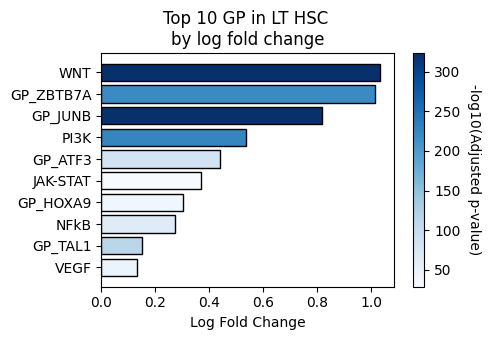

In [21]:
plot_gp_score_fold_change(dfi.sort_values(by = 'logfoldchanges', ascending = False),
                         title_ct = 'LT HSC', 
                          save_to = 'hsc_gp.pdf'
                         )

In [ ]:
pert_data.obs['cell_type'].cat.categories

In [68]:
prog = pert_data[pert_data.obs['cell_type'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP', '4_MEMP',
                                                  '9_LMPP','21_GMP',
                                                ])]

In [69]:
dfp = sc.get.rank_genes_groups_df(prog, group = '1_LT-HSC')

In [70]:
dfp.head(n=10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,WNT,54.500797,1.033857,0.000000e+00,0.000000e+00
1,GP_JUNB,42.633976,0.818712,0.000000e+00,0.000000e+00
2,PI3K,33.505581,0.535627,1.185080e-228,4.848053e-228
3,GP_ZBTB7A,32.944706,1.013947,3.289933e-221,1.233725e-220
4,GP_TAL1,23.161880,0.149073,1.027006e-114,2.888453e-114
5,GP_ATF3,19.835228,0.440175,2.597694e-85,5.844812e-85
6,NFkB,17.365667,0.271945,3.168475e-66,5.940891e-66
7,VEGF,14.601414,0.132042,1.099381e-47,1.766863e-47
8,GP_HOXA9,13.453439,0.301043,9.115939e-41,1.323281e-40
9,JAK-STAT,11.353052,0.367667,1.308239e-29,1.839711e-29


In [71]:
dfp.sort_values(by = 'logfoldchanges', ascending = False).head(n=10)

,names,scores,logfoldchanges,pvals,pvals_adj
0,WNT,54.500797,1.033857,0.000000e+00,0.000000e+00
3,GP_ZBTB7A,32.944706,1.013947,3.289933e-221,1.233725e-220
1,GP_JUNB,42.633976,0.818712,0.000000e+00,0.000000e+00
2,PI3K,33.505581,0.535627,1.185080e-228,4.848053e-228
5,GP_ATF3,19.835228,0.440175,2.597694e-85,5.844812e-85
9,JAK-STAT,11.353052,0.367667,1.308239e-29,1.839711e-29
8,GP_HOXA9,13.453439,0.301043,9.115939e-41,1.323281e-40
6,NFkB,17.365667,0.271945,3.168475e-66,5.940891e-66
4,GP_TAL1,23.161880,0.149073,1.027006e-114,2.888453e-114
7,VEGF,14.601414,0.132042,1.099381e-47,1.766863e-47


In [ ]:
sc.pl.matrixplot(
    pert_data, 
    var_names=dfi['names'][:5],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'All HSC'
)


In [ ]:
sc.pl.matrixplot(
    pert_data, 
    var_names=dfi.sort_values(by = 'logfoldchanges', ascending = False).head(n=10)['names'],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'All HSC'
)


In [ ]:
# Step 1: Select top genes
top_genes = dfi.sort_values(by='logfoldchanges', ascending=False).head(10)['names'].values

# Step 2: Compute mean expression per group (cell_type)
expr = pd.DataFrame(
    pert_data[:, top_genes].X.toarray() if hasattr(pert_data[:, top_genes].X, "toarray") else pert_data[:, top_genes].X,
    index=pert_data.obs_names,
    columns=top_genes
)
expr['cell_type'] = pert_data.obs['cell_type'].values
group_means = expr.groupby('cell_type').mean()

# Step 3: Rank each gene's expression across cell types
ranks = group_means.rank(axis=0, method='min', ascending=False)

# Step 4: Normalize ranks to [0, 1] (so 1 = highest expression)
normalized_ranks = (ranks.max() - ranks) / (ranks.max() - ranks.min())

# Step 5: matrixplot using precomputed DataFrame
sc.pl.matrixplot(
    pert_data,  # can be any AnnData, we’re bypassing .X by using values_df
    var_names=top_genes,
    groupby='cell_type',
    values_df=normalized_ranks,
    cmap='BuPu',
    swap_axes=True,
    title='All HSC (Rank-Based Color)'
)


In [ ]:
prog = [
    '1_LT-HSC', 
    '2_ST-HSC',
    '3_MPP', 
    '4_MEMP',
    '9_LMPP', 
    '10_CLP', 
    '21_GMP'
]

In [ ]:
# Step 5: matrixplot using precomputed DataFrame
sc.pl.matrixplot(
    pert_data[pert_data.obs['cell_type'].isin(prog)], 
    var_names=top_genes,
    groupby='cell_type',
    values_df=normalized_ranks[normalized_ranks.index.isin(prog)],
    cmap='BuPu',
    swap_axes=True,
    title='HSC (Rank-Based Color)'
)


In [ ]:
prog_data = pert_data[pert_data.obs['cell_type'].isin(prog)]

# Step 1: Select top genes
top_genes = dfi.sort_values(by='logfoldchanges', ascending=False).head(10)['names'].values

# Step 2: Compute mean expression per group (cell_type)
expr = pd.DataFrame(
    prog_data[:, top_genes].X.toarray() if hasattr(prog_data[:, top_genes].X, "toarray") else prog_data[:, top_genes].X,
    index=prog_data.obs_names,
    columns=top_genes
)
expr['cell_type'] = prog_data.obs['cell_type'].values
group_means = expr.groupby('cell_type').mean()

# Step 3: Rank each gene's expression across cell types
ranks = group_means.rank(axis=0, method='min', ascending=False)

# Step 4: Normalize ranks to [0, 1] (so 1 = highest expression)
normalized_ranks = (ranks.max() - ranks) / (ranks.max() - ranks.min())

# Step 5: matrixplot using precomputed DataFrame
sc.pl.matrixplot(
    prog_data,  # can be any AnnData, we’re bypassing .X by using values_df
    var_names=top_genes,
    groupby='cell_type',
    values_df=normalized_ranks,
    cmap='BuPu',
    swap_axes=True,
    title='All HSC (Rank-Based Color)'
)


In [ ]:
sc.pl.matrixplot(
    prog_data, 
    var_names=dfi.sort_values(by = 'logfoldchanges', ascending = False).head(n=10)['names'],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
    title = 'All HSC'
)


# Plot core GP?

In [ ]:
for gp in ['WNT', 'GP_HOXA9', 'GP_FOXO3',]:
    make_barplot(pert_data, 
                 gp, 
                 pert_data.obs['cell_type'].cat.categories, 
                 fig_size = (25, 5))


In [ ]:
sc.pl.matrixplot(
    pert_data, 
    var_names=['WNT', 'VEGF', 
               # 'GP_USF1', 
               'GP_HOXA9', 'GP_FOXO3', 'GP_JUNB'],
    groupby='cell_type',
    standard_scale='var',
    cmap='BuPu',
    swap_axes = True,
)


In [ ]:
for t in pert_data.obs['tissue'].cat.categories:
    sc.pl.matrixplot(
        pert_data[pert_data.obs['tissue'] == t], 
        var_names=['WNT', 'VEGF', 
                   # 'GP_USF1', 
                   'GP_HOXA9', 'GP_FOXO3', 'GP_JUNB'],
        groupby='cell_type',
        standard_scale='var',
        cmap='BuPu',
        swap_axes = True,
        title = t
    )


In [51]:
import statsmodels.formula.api as smf

In [52]:
df = pert_data.obs.copy()
df['gp_score'] = pert_data[:, pert_data.var.index == 'Hypoxia'].X.toarray().flatten()  # score for GP j

In [53]:
df.head()

,length,scaled_length,runid_mrna_sample,age,sorting,sex,tissue,age_general,phase,S_score,...,S.Score,G2M.Score,CyclePhase,AuthorCellType,development_stage,source_id,batch_key_id,cell_type_id,tissue_study,gp_score
1,347,347,SLX19554_SIGAD6,32.0,CD34,M,ABM_29-50y,Young adult,G2M,-0.038977463014909175,...,NaN,NaN,NaN,NaN,NaN,0,0,15,ABM_29-50y_Isobe_CD34,0.000709
7,1316,1316,SLX19554_SIGAA6,,CD34,F,FL,Prenatal,G1,-0.30238237039322424,...,NaN,NaN,NaN,NaN,NaN,0,0,13,FL_Isobe_CD34,0.001315
9,324,324,SLX19160_SIGAG7,0.0,CD34,M,CB,Neonatal,G1,-0.02341571770145394,...,NaN,NaN,NaN,NaN,NaN,0,0,9,CB_Isobe_CD34,0.001010
10,1017,1017,SLX19554_SIGAD7,29.0,CD34,M,ABM_29-50y,Young adult,S,0.0837652228747722,...,NaN,NaN,NaN,NaN,NaN,0,0,6,ABM_29-50y_Isobe_CD34,0.000100
11,1317,1317,SLX19554_SIGAF3,64.0,CD34,F,ABM_+60y,Adult,G2M,-0.10552757047735575,...,NaN,NaN,NaN,NaN,NaN,0,0,6,ABM_+60y_Isobe_CD34,0.000668


In [55]:
adata = pert_data

In [56]:
import numpy as np
from scipy.stats import ttest_ind

gp_scores = adata.X  # shape (cells, GPs)
labels = adata.obs['cell_type'] == '1_LT-HSC'

cohen_d = (gp_scores[labels].mean(0) - gp_scores[~labels].mean(0)) / \
           np.sqrt(0.5 * (gp_scores[labels].var(0) + gp_scores[~labels].var(0)))


In [57]:
cohen_d.shape

(45,)

In [58]:
cohen_d_out = pd.DataFrame(
    {'gp' : adata.var_names,
     'cohen_d' : cohen_d
    }
)

In [59]:
cohen_d_out.sort_values(by = 'cohen_d', ascending = False)[:10]

,gp,cohen_d
44,WNT,0.763321
12,GP_JUNB,0.568071
29,GP_ZBTB7A,0.486080
39,PI3K,0.465394
16,GP_TAL1,0.289618
11,GP_ATF3,0.264387
37,NFkB,0.229172
28,GP_HOXA9,0.182522
35,JAK-STAT,0.167031
43,VEGF,0.164638


In [60]:
gp_scores.shape

(98266, 45)

In [61]:
from scipy.stats import ranksums
pvals = [ranksums(gp_scores[labels, i], gp_scores[~labels, i]).pvalue for i in range(gp_scores.shape[1])]


In [62]:
len(pvals)

45

In [63]:
pvals_out = pd.DataFrame(
    {'gp' : adata.var_names,
     'pval' : pvals
    }
)

In [64]:
pvals_out.sort_values(by = 'pval')[:10]

,gp,pval
44,WNT,0.0
42,Trail,0.0
39,PI3K,0.0
38,p53,0.0
5,GP_E2F4,0.0
34,Hypoxia,0.0
29,GP_ZBTB7A,0.0
25,GP_IKZF1,0.0
12,GP_JUNB,0.0
18,GP_ELF1,0.0
